In [ ]:
"1"

In [1]:
import numpy as np
from scipy import stats

def check_normality(data):
    """
    Проверка нормальности распределения выборки с помощью теста Шапиро-Уилка
    
    Параметры:
    data: массив или список с данными
    
    Возвращает:
    tuple: (статистика теста, p-value)
    """
    # Очистка от пропущенных значений (если есть)
    data_clean = np.array(data)[~np.isnan(data)]
    
    # Проверка минимального объема выборки
    if len(data_clean) < 3:
        print("Ошибка: выборка слишком мала для проверки нормальности (нужно минимум 3 элемента)")
        return None, None
    
    # Тест Шапиро-Уилка
    statistic, p_value = stats.shapiro(data_clean)
    
    # Уровень значимости (стандартно 0.05)
    alpha = 0.05
    
    print(f"Тест Шапиро-Уилка: статистика = {statistic:.4f}, p-value = {p_value:.4f}")
    print(f"Уровень значимости α = {alpha}")
    print("-" * 50)
    
    # Условие статистической значимости
    if p_value < alpha:
        print("Отклоняем нулевую гипотезу >> Данные распределены не нормально")
    else:
        print("Не отклоняем нулевую гипотезу >> Данные распределены нормально")
    
    return statistic, p_value

In [2]:
"2"

'2'

ОПИСАТЕЛЬНЫЕ СТАТИСТИКИ
Мужчины: n = 13, среднее = 178.38, std = 2.75
Женщины: n = 13, среднее = 167.08, std = 1.80
Разница средних = 11.31

ПРОВЕРКА НОРМАЛЬНОСТИ
Мужчины: p-value = 0.9453
  → Мужчины: распределение нормальное
Женщины: p-value = 0.8109
  → Женщины: распределение нормальное

ПРОВЕРКА РАВЕНСТВА ДИСПЕРСИЙ (тест Левена)
Тест Левена: p-value = 0.1396
Дисперсии равны → используем классический t-тест Стьюдента

t-ТЕСТ СТЬЮДЕНТА (α = 0.001)
t-статистика = 12.3870
p-value = 0.000000
Уровень значимости α = 0.001
------------------------------------------------------------
РЕЗУЛЬТАТ: Отклоняем нулевую гипотезу (H₀)
→ Различие между выборками СТАТИСТИЧЕСКИ ЗНАЧИМО на уровне α = 0.001
  (p-value = 0.000000 < 0.001)

ВИЗУАЛИЗАЦИЯ РАЗЛИЧИЙ


C:\Users\ushak\AppData\Local\Temp\ipykernel_10400\1413007123.py:82: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot([men_heights, women_heights],


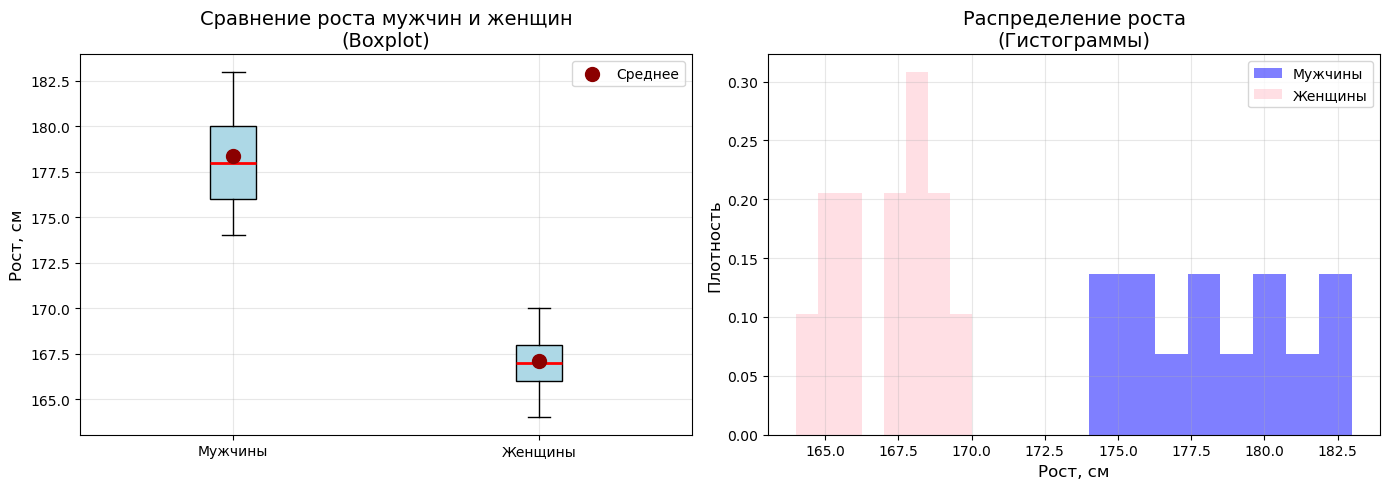

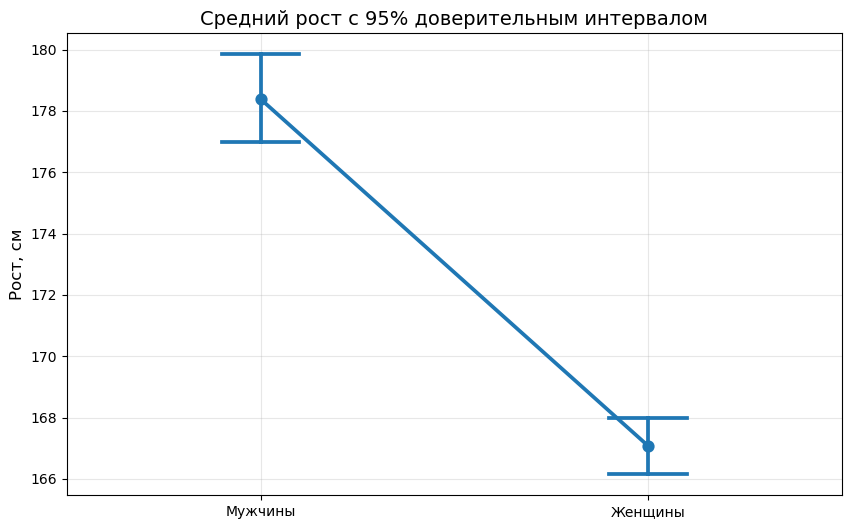

In [3]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

# ========== ВАШИ ДАННЫЕ ==========
# Вместо этих чисел подставьте свои выборки
men_heights = np.array([175, 180, 178, 182, 176, 179, 181, 177, 174, 183, 176, 178, 180])
women_heights = np.array([165, 168, 167, 169, 166, 170, 164, 168, 167, 169, 165, 166, 168])

# ==================================

alpha = 0.001  # уровень значимости

# Описательные статистики
print("="*60)
print("ОПИСАТЕЛЬНЫЕ СТАТИСТИКИ")
print("="*60)
print(f"Мужчины: n = {len(men_heights)}, среднее = {np.mean(men_heights):.2f}, std = {np.std(men_heights, ddof=1):.2f}")
print(f"Женщины: n = {len(women_heights)}, среднее = {np.mean(women_heights):.2f}, std = {np.std(women_heights, ddof=1):.2f}")
print(f"Разница средних = {np.mean(men_heights) - np.mean(women_heights):.2f}")

# Проверка нормальности (важное предположение t-теста)
print("\n" + "="*60)
print("ПРОВЕРКА НОРМАЛЬНОСТИ")
print("="*60)

def check_normality(data, name):
    stat, p = stats.shapiro(data)
    print(f"{name}: p-value = {p:.4f}")
    if p < 0.05:
        print(f"  → {name}: распределение НЕ нормальное")
    else:
        print(f"  → {name}: распределение нормальное")

check_normality(men_heights, "Мужчины")
check_normality(women_heights, "Женщины")

# Проверка равенства дисперсий (тест Левена)
print("\n" + "="*60)
print("ПРОВЕРКА РАВЕНСТВА ДИСПЕРСИЙ (тест Левена)")
print("="*60)
levene_stat, levene_p = stats.levene(men_heights, women_heights)
print(f"Тест Левена: p-value = {levene_p:.4f}")
if levene_p < 0.05:
    print("Дисперсии НЕ равны → используем t-тест Уэлча (equal_var=False)")
    equal_var = False
else:
    print("Дисперсии равны → используем классический t-тест Стьюдента")
    equal_var = True

# t-тест Стьюдента
print("\n" + "="*60)
print("t-ТЕСТ СТЬЮДЕНТА (α = 0.001)")
print("="*60)

t_stat, p_value = stats.ttest_ind(men_heights, women_heights, equal_var=equal_var)

print(f"t-статистика = {t_stat:.4f}")
print(f"p-value = {p_value:.6f}")
print(f"Уровень значимости α = {alpha}")
print("-"*60)

# УСЛОВИЕ ЗАДАНИЯ: доказываем, что различие НЕЗНАЧИТЕЛЬНО
if p_value > alpha:
    print("РЕЗУЛЬТАТ: Не отклоняем нулевую гипотезу (H₀)")
    print("→ Различие между выборками НЕЗНАЧИМО на уровне α = 0.001")
    print(f"  (p-value = {p_value:.6f} > {alpha})")
else:
    print("РЕЗУЛЬТАТ: Отклоняем нулевую гипотезу (H₀)")
    print("→ Различие между выборками СТАТИСТИЧЕСКИ ЗНАЧИМО на уровне α = 0.001")
    print(f"  (p-value = {p_value:.6f} < {alpha})")

# ВИЗУАЛИЗАЦИЯ
print("\n" + "="*60)
print("ВИЗУАЛИЗАЦИЯ РАЗЛИЧИЙ")
print("="*60)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График 1: Boxplot (ящик с усами)
axes[0].boxplot([men_heights, women_heights], 
                labels=['Мужчины', 'Женщины'],
                patch_artist=True,
                boxprops=dict(facecolor='lightblue'),
                medianprops=dict(color='red', linewidth=2))
axes[0].set_ylabel('Рост, см', fontsize=12)
axes[0].set_title('Сравнение роста мужчин и женщин\n(Boxplot)', fontsize=14)
axes[0].grid(True, alpha=0.3)

# Добавляем средние значения
axes[0].scatter([1, 2], [np.mean(men_heights), np.mean(women_heights)], 
                color='darkred', s=100, zorder=5, label='Среднее')
axes[0].legend()

# График 2: Гистограммы с KDE
axes[1].hist(men_heights, bins=8, alpha=0.5, label='Мужчины', color='blue', density=True)
axes[1].hist(women_heights, bins=8, alpha=0.5, label='Женщины', color='pink', density=True)
axes[1].set_xlabel('Рост, см', fontsize=12)
axes[1].set_ylabel('Плотность', fontsize=12)
axes[1].set_title('Распределение роста\n(Гистограммы)', fontsize=14)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Дополнительная визуализация: точечный график с доверительными интервалами
plt.figure(figsize=(10, 6))
sns.pointplot(data=[men_heights, women_heights], errorbar='ci', capsize=0.2)
plt.xticks([0, 1], ['Мужчины', 'Женщины'])
plt.ylabel('Рост, см', fontsize=12)
plt.title('Средний рост с 95% доверительным интервалом', fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()

In [4]:
"3"

'3'

In [ ]:
import scipy.stats as stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import numpy as np
import pandas as pd

dev = [5.2, 4.8, 6.1, 5.5, 5.9, 4.5, 5.0, 6.3, 5.7, 4.9, 5.4, 6.0, 5.1, 4.7, 5.8, 6.2, 5.3]
test = [6.5, 7.0, 6.8, 7.2, 6.9, 7.4, 6.7, 7.1, 6.6, 7.3, 6.4, 7.5, 6.2, 7.0, 6.8, 7.6, 6.9]

shapiro_dev = stats.shapiro(dev)
shapiro_test = stats.shapiro(test)

print(f"Разработчики: W={shapiro_dev.statistic:.3f}, p={shapiro_dev.pvalue:.3f}")
print(f"Тестировщики: W={shapiro_test.statistic:.3f}, p={shapiro_test.pvalue:.3f}")

In [ ]:
levene_stat, levene_p = stats.levene(dev, test)
print(f"Левен: p={levene_p:.3f}")

In [ ]:
t_stat, p_value = stats.ttest_ind(dev, test, equal_var=(levene_p > 0.05))
print(f"t = {t_stat:.3f}, p = {p_value:.3f}")

In [5]:
"4"

SyntaxError: unterminated string literal (detected at line 1) (340504569.py, line 1)

In [ ]:
import scipy.stats as stats
import pandas as pd

# Пример данных (замените на свои)
группа1 = [520, 540, 530, 515, 535, 525, 545, 510, 530, 525]  # только грудное
группа2 = [480, 490, 485, 475, 495, 480, 500, 470, 485, 490]  # только смесь
группа3 = [500, 510, 505, 495, 515, 505, 520, 495, 510, 505]  # смесь+грудь

for i, data in enumerate([группа1, группа2, группа3], 1):
    stat, p = stats.shapiro(data)
    print(f"Группа {i}: W={stat:.3f}, p={p:.3f}")

In [ ]:
levene_stat, levene_p = stats.levene(группа1, группа2, группа3)
print(f"Левен: p={levene_p:.3f}")

In [ ]:
f_stat, p_value = stats.f_oneway(группа1, группа2, группа3)
print(f"F = {f_stat:.3f}, p = {p_value:.4f}")

In [ ]:

data = np.concatenate([группа1, группа2, группа3])
groups = ['Грудное']*len(группа1) + ['Смесь']*len(группа2) + ['Смешанное']*len(группа3)

tukey = pairwise_tukeyhsd(data, groups, alpha=0.05)
print(tukey)